# Lab Work: Developing and Comparing AI Models for Android Malware Detection

## Objective:
The goal of this lab is to develop and evaluate multiple AI models for detecting Android malware using the provided Android Malware Dataset. Students will choose at least three different machine learning or deep learning algorithms to compare their performance in classifying Android applications as benign or malicious.

## Dataset Overview:
The **Android Malware Dataset for Machine Learning** contains labeled Android APK samples, classified as benign (goodware) or malicious (e.g., adware, spyware, trojans). It includes various features extracted from the APKs, such as requested permissions, API calls, system behaviors, and more, which can be used to train machine learning models.

## Tasks:

1. **Data Preprocessing**:
   - Load the dataset and clean it by handling missing values and converting categorical features into numerical ones if necessary.
   - Split the data into training and testing sets.

2. **Model Development**:
   - Choose at least **three AI algorithms** of your choice (e.g., Logistic Regression, Random Forest, SVM, Neural Networks, XGBoost, etc.).
   - Train each model on the dataset and evaluate their performance using accuracy, precision, recall, F1-score, and confusion matrix.

3. **Model Comparison**:
   - Compare the models based on their performance metrics.
   - Analyze which model performs best and why.

4. **Optional (Hyperparameter Tuning)**:
   - Optionally, apply techniques like grid search to optimize the model’s hyperparameters.


## Resources:
- Kaggle Dataset: [Android Malware Dataset for Machine Learning](https://www.kaggle.com/datasets/shashwatwork/android-malware-dataset-for-machine-learning)

You need to login in Kaggle to get access to the dataset.


# **Load Dataset**

In [30]:
import pandas as pd

df = pd.read_csv("drebin-215-dataset-5560malware-9476-benign.csv", low_memory=False)

print("Shape:", df.shape)
print(df.head())

Shape: (15036, 216)
   transact  onServiceConnected  bindService  attachInterface  \
0         0                   0            0                0   
1         0                   0            0                0   
2         0                   0            0                0   
3         0                   0            0                0   
4         0                   0            0                0   

   ServiceConnection  android.os.Binder  SEND_SMS  \
0                  0                  0         1   
1                  0                  0         1   
2                  0                  0         1   
3                  0                  0         0   
4                  0                  0         0   

   Ljava.lang.Class.getCanonicalName  Ljava.lang.Class.getMethods  \
0                                  0                            0   
1                                  0                            0   
2                                  0                           

## Data Preprocessing

In [31]:
df = df.dropna(axis=1, how='all')
df = df.fillna(0)

### Encode Categorical Columns

In [32]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.select_dtypes(include=['object', 'bool']).columns:
    if col != "class":
        df[col] = encoder.fit_transform(df[col].astype(str))

## Define Features & Target


In [33]:
X = df.drop("class", axis=1)
y = df["class"]

print(X.shape)

(15036, 215)


## Define Features & Target


In [34]:
X = df.drop("class", axis=1)
y = df["class"]

print(X.shape)

(15036, 215)


## Train-Test Split


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

## Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## SVM

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

svm = SVC(kernel="linear")
svm.fit(X_train_s, y_train)
y_pred_svm = svm.predict(X_test_s)

## Evaluation Function

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label='S', zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label='S', zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, pos_label='S', zero_division=0)
    }

## Collect Results

In [40]:
results = {
    "Logistic Regression": get_metrics(y_test, y_pred_lr),
    "Random Forest": get_metrics(y_test, y_pred_rf),
    "SVM": get_metrics(y_test, y_pred_svm)
}

results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.978391   0.974615  0.966727  0.970655
Random Forest        0.986370   0.989936  0.973022  0.981406
SVM                  0.981383   0.977396  0.972122  0.974752


## GRAPH

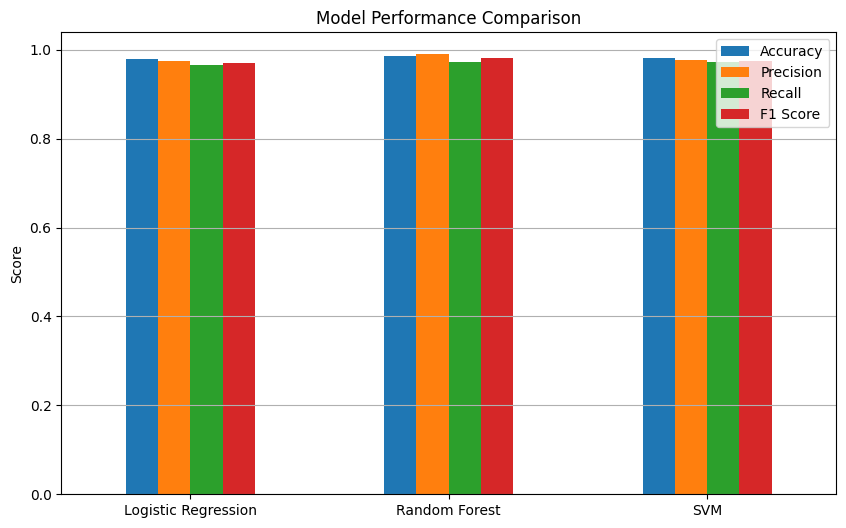

In [41]:
import matplotlib.pyplot as plt

results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

## Confusion Matrix (for best model)

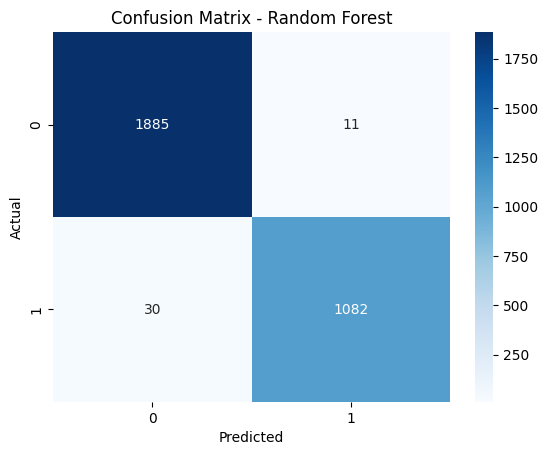

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Lab Logbook requirement**: Provide a graph comparing the performance of the AI model that you have developed.